# IMPORTS

In [24]:
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.stats import norm
import sys
import os
from dotenv import load_dotenv
from fredapi import Fred
import QuantLib as ql


In [25]:
# Agregar el directorio scripts al path
scripts_path = os.path.join(os.path.dirname(os.getcwd()), 'scripts')
if scripts_path not in sys.path:
    sys.path.insert(0, scripts_path)

# Importar todas las funciones del módulo black_scholes
from black_scholes import *
from dividends import *
from data_loader import *
from rates import *
from straddle import *

# Fase 0

In [26]:
# obhetivo: DataFrame con fechas alineadas de SPY close, VIX close, y tasas Treasury
start_date = '2025-11-29'
end_date = '2025-12-29'

spy_data = get_spy_history(start_date, end_date)
vix_data = get_vix_history(start_date, end_date)
treasury_data = load_treasury_curve(start_date, end_date)

# Combinar los datos en un solo DataFrame
combined_data = spy_data.join(vix_data, how='inner').join(treasury_data, how='inner')

In [27]:
combined_data

,close_spy,q_yield,close_vix,30,90,180,365
2025-12-01,680.270020,0.010663,0.1724,0.0398,0.0381,0.0375,0.0362
2025-12-02,681.530029,0.010644,0.1659,0.0390,0.0377,0.0372,0.0359
2025-12-03,683.890015,0.010607,0.1608,0.0383,0.0372,0.0368,0.0357
2025-12-04,684.390015,0.010599,0.1578,0.0383,0.0371,0.0369,0.0360
2025-12-05,685.690002,0.010579,0.1541,0.0382,0.0371,0.0368,0.0361
2025-12-08,683.630005,0.010611,0.1666,0.0382,0.0373,0.0369,0.0361
2025-12-09,683.039978,0.010620,0.1693,0.0381,0.0373,0.0370,0.0363
2025-12-10,687.570007,0.010550,0.1577,0.0379,0.0369,0.0366,0.0358
2025-12-11,689.169983,0.010526,0.1485,0.0377,0.0366,0.0362,0.0356
2025-12-12,681.760010,0.010640,0.1574,0.0376,0.0363,0.0358,0.0354


# Fase 1

In [28]:
# Caso estándar para verificar la formula de Black-Scholes
S = 689
K = 689.1
T = 0.00547945205
r = 0.0364
sigma = 0.07
q=5

call_price = black_scholes_merton(S, K, T, r, q, sigma, option_type='call')
put_price = black_scholes_merton(S, K, T, r, q, sigma, option_type='put')
# Call ≈ 5.45, Put ≈ 4.71 (verificar con QuantLib)

In [29]:
call_price, put_price

(np.float64(4.114400224971513e-08), np.float64(18.58304396956305))

comparar contra tws y contra quantlib

# Fase 2

In [30]:
call_greeks = calculate_all_greeks(S, K, T, r, q, sigma, option_type='call')

In [31]:
call_greeks

{'delta': np.float64(6.482930372454497e-08),
 'gamma': np.float64(9.900560031308451e-08),
 'vega': np.float64(1.8027411661135303e-07),
 'theta': np.float64(2.9195195583778394e-07),
 'rho': np.float64(2.4452737657487013e-09)}

In [32]:
put_greeks = calculate_all_greeks(S, K, T, r, q, sigma, option_type='put')

In [33]:
put_greeks

{'delta': np.float64(-0.9729745757605611),
 'gamma': np.float64(9.900560031308451e-08),
 'vega': np.float64(1.8027411661135303e-07),
 'theta': np.float64(-9.114573404587638),
 'rho': np.float64(-0.03775137129127382)}

comparar contra tws y contra quantlib

# Fase 3

In [34]:
q = implied_dividend_yield(call_price, put_price, S, K, r, T)

In [35]:
q

np.float64(5.000000000000031)

# Fase 4

In [36]:
greeks_straddle = calculate_straddle_greeks(S, K, T, r, q, sigma)
greeks_straddle

{'delta': np.float64(-0.9729745109312572),
 'gamma': np.float64(1.980112006261338e-07),
 'vega': np.float64(3.6054823322264206e-07),
 'theta': np.float64(-9.114573112635737),
 'rho': np.float64(-0.037751368846000055)}

In [37]:
precio_straddle = price_straddle(S, K, T, r, q, sigma)
precio_straddle

{'call': np.float64(4.114400224980322e-08),
 'put': np.float64(18.583043969563164),
 'straddle': np.float64(18.583044010707166)}

# Fase 5

{'total_pnl_straddle': np.float64(-30.878618502863787), 'num_trades': 12, 'avg_pnl_per_trade': np.float64(-2.573218208571982), 'win_rate': 0.5, 'avg_win': np.float64(6.074264164042414), 'avg_loss': np.float64(-11.220700581186378), 'best_trade': np.float64(9.736999969165026), 'worst_trade': np.float64(-24.656496296033254), 'open_positions': 0, 'total_pnl': np.float64(-129.4557143918777), 'max_drawdown': -403.71752868594297, 'profit_factor': np.float64(0.5413444659798751)}


<Axes: >

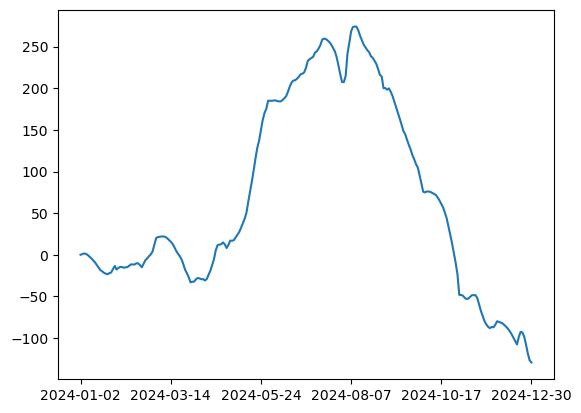

In [38]:
from data_loader import get_spy_history, get_vix_history, load_treasury_curve
from strategy import generate_entry_dates
from backtest import run_backtest, prepare_market_data

# 1. Cargar datos
spy = get_spy_history('2024-01-01', '2024-12-31')
vix = get_vix_history('2024-01-01', '2024-12-31')
treasury = load_treasury_curve('2024-01-01', '2024-12-31')

# 2. Consolidar
market_data = prepare_market_data(spy, vix, treasury)

# 3. Generar fechas de entrada
entry_dates = generate_entry_dates('2024-01-01', '2024-12-31', market_data.index, 'monthly')

# 4. Ejecutar backtest
results = run_backtest(market_data, entry_dates, tenor_days=30)

# 5. Analizar
print(results.summary)
results.cumulative_pnl_straddle.plot()

# Fase 6

In [39]:
import plotly.graph_objects as go

# Crear figura única
fig = go.Figure()

# 1. Sin hedge
results_no_hedge = run_backtest(market_data, entry_dates, tenor_days=30)
fig.add_trace(
    go.Scatter(x=results_no_hedge.cumulative_pnl_straddle.index, 
               y=results_no_hedge.cumulative_pnl_straddle.values,
               mode='lines', name='Sin Hedge', line=dict(color='blue', width=2))
)

# 2. Hedge diario
config_daily = HedgeConfig(rebalance_freq='daily', multiplier=100)
results_daily = run_backtest(market_data, entry_dates, tenor_days=30, hedge_config=config_daily)
fig.add_trace(
    go.Scatter(x=results_daily.cumulative_pnl_hedge.index,
               y=results_daily.cumulative_pnl_hedge.values,
               mode='lines', name='Hedge Diario', line=dict(color='green', width=2))
)

# 3. Hedge semanal
config_weekly = HedgeConfig(rebalance_freq='weekly', multiplier=100)
results_weekly = run_backtest(market_data, entry_dates, tenor_days=30, hedge_config=config_weekly)
fig.add_trace(
    go.Scatter(x=results_weekly.cumulative_pnl_hedge.index,
               y=results_weekly.cumulative_pnl_hedge.values,
               mode='lines', name='Hedge Semanal', line=dict(color='orange', width=2))
)

# 4. Hedge por umbral
config_threshold = HedgeConfig(rebalance_freq='threshold', delta_threshold=0.15, multiplier=100)
results_threshold = run_backtest(market_data, entry_dates, tenor_days=30, hedge_config=config_threshold)
fig.add_trace(
    go.Scatter(x=results_threshold.cumulative_pnl_hedge.index,
               y=results_threshold.cumulative_pnl_hedge.values,
               mode='lines', name='Hedge por Umbral (|Δ|>0.15)', line=dict(color='purple', width=2))
)

# 5. Con costes
config_costs = HedgeConfig(rebalance_freq='daily', include_costs=True, cost_per_share=0.02, multiplier=100)
results_costs = run_backtest(market_data, entry_dates, tenor_days=30, hedge_config=config_costs)
fig.add_trace(
    go.Scatter(x=results_costs.cumulative_pnl_hedge.index,
               y=results_costs.cumulative_pnl_hedge.values,
               mode='lines', name='Hedge Diario con Costes ($0.02/acción)', line=dict(color='red', width=2))
)

# Actualizar layout
fig.update_layout(
    title='Comparación de Estrategias de Hedge - PnL Acumulado 2024',
    xaxis_title='Fecha',
    yaxis_title='PnL Acumulado ($)',
    legend=dict(x=0.02, y=0.98, bgcolor='rgba(255,255,255,0.8)'),
    hovermode='x unified',
    height=600,
    width=1200
)

fig.show()

# Guardar resultado para uso posterior
results = results_costs


# Evolución de las Griegas

In [40]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Parámetros base
K = 689.1  # Strike
T = 30/365  # 30 días
r = 0.0364  # Tasa libre de riesgo
q = 0.010632  # Dividend yield
sigma = 0.1491  # Volatilidad implícita (VIX)

# Rango de precios del subyacente (±20% alrededor del strike)
spot_prices = np.linspace(K * 0.8, K * 1.2, 100)

# Almacenar las griegas
deltas = []
gammas = []
vegas = []
thetas = []
rhos = []

# Calcular griegas para cada precio spot
for S in spot_prices:
    greeks = calculate_straddle_greeks(S, K, T, r, q, sigma)
    deltas.append(greeks['delta'])
    gammas.append(greeks['gamma'])
    vegas.append(greeks['vega'])
    thetas.append(greeks['theta'])
    rhos.append(greeks['rho'])

# Crear subplots
fig = make_subplots(
    rows=5, cols=1,
    subplot_titles=('Delta', 'Gamma', 'Vega', 'Theta', 'Rho'),
    vertical_spacing=0.08,
    specs=[[{"secondary_y": False}]] * 5
)

# Delta
fig.add_trace(
    go.Scatter(x=spot_prices, y=deltas, name='Delta', 
               line=dict(color='blue', width=2), showlegend=False),
    row=1, col=1
)

# Gamma
fig.add_trace(
    go.Scatter(x=spot_prices, y=gammas, name='Gamma',
               line=dict(color='green', width=2), showlegend=False),
    row=2, col=1
)

# Vega
fig.add_trace(
    go.Scatter(x=spot_prices, y=vegas, name='Vega',
               line=dict(color='orange', width=2), showlegend=False),
    row=3, col=1
)

# Theta
fig.add_trace(
    go.Scatter(x=spot_prices, y=thetas, name='Theta',
               line=dict(color='red', width=2), showlegend=False),
    row=4, col=1
)

# Rho
fig.add_trace(
    go.Scatter(x=spot_prices, y=rhos, name='Rho',
               line=dict(color='purple', width=2), showlegend=False),
    row=5, col=1
)

# Agregar línea vertical en el strike
for i in range(1, 6):
    fig.add_vline(x=K, line_dash="dash", line_color="gray", opacity=0.5, row=i, col=1)

# Actualizar ejes
fig.update_xaxes(title_text="Precio del Subyacente ($)", row=5, col=1)
for i in range(1, 6):
    fig.update_yaxes(title_text="Valor", row=i, col=1)

# Layout general
fig.update_layout(
    title=f'Evolución de las Griegas del Straddle (K=${K:.2f}, T={T*365:.0f} días, σ={sigma:.2%})',
    height=1200,
    width=1000,
    hovermode='x unified',
    showlegend=False
)

fig.show()

In [41]:
# Versión con todas las griegas en un mismo gráfico (normalizadas)
from sklearn.preprocessing import StandardScaler

# Normalizar las griegas para visualización en el mismo gráfico
scaler = StandardScaler()
greeks_matrix = np.column_stack([deltas, gammas, vegas, thetas, rhos])
greeks_normalized = scaler.fit_transform(greeks_matrix)

fig_combined = go.Figure()

# Agregar cada griega normalizada
fig_combined.add_trace(
    go.Scatter(x=spot_prices, y=greeks_normalized[:, 0], 
               name='Delta', line=dict(color='blue', width=2))
)
fig_combined.add_trace(
    go.Scatter(x=spot_prices, y=greeks_normalized[:, 1], 
               name='Gamma', line=dict(color='green', width=2))
)
fig_combined.add_trace(
    go.Scatter(x=spot_prices, y=greeks_normalized[:, 2], 
               name='Vega', line=dict(color='orange', width=2))
)
fig_combined.add_trace(
    go.Scatter(x=spot_prices, y=greeks_normalized[:, 3], 
               name='Theta', line=dict(color='red', width=2))
)
fig_combined.add_trace(
    go.Scatter(x=spot_prices, y=greeks_normalized[:, 4], 
               name='Rho', line=dict(color='purple', width=2))
)

# Línea vertical en el strike
fig_combined.add_vline(x=K, line_dash="dash", line_color="gray", opacity=0.5)

fig_combined.update_layout(
    title=f'Evolución de Griegas Normalizadas del Straddle (K=${K:.2f}, T={T*365:.0f} días)',
    xaxis_title='Precio del Subyacente ($)',
    yaxis_title='Valor Normalizado (Z-score)',
    hovermode='x unified',
    height=600,
    width=1000,
    legend=dict(x=0.02, y=0.98, bgcolor='rgba(255,255,255,0.8)')
)

fig_combined.show()